## Methodology

In this notebook, we evaluate how well different LLMs can identify metaphor usage in text by comparing their outputs against human-labeled data.

We use the survey dataset from *“From Tools to Thieves” (Cheng et al.)* as the reference benchmark. The dataset contains open-ended responses where participants described AI using metaphors, along with manually annotated “dominant metaphor” labels.

The metaphor categories are based on Cheng et al.’s taxonomy, summarized in the figure below.

<div style="text-align: center;">
    <img src="../Docs_Images/Metaphors_Myra_Cheng.png" width="65%">
    <p style="font-size: 12px; color: gray;">
        Figure 1: Metaphor categories adapted from Cheng et al. (2025).
    </p>
</div>

From the full set of metaphors in the paper, we restrict the evaluation to the categories that overlap exactly with the categories used in FrameScope. This avoids introducing subjective mapping decisions between taxonomies.

For each response:
- We prompt GPT and LLaMA-based models to predict the dominant metaphor.
- We compare the model prediction directly with the human-labeled metaphor.
- We evaluate model performance using standard classification metrics.

The goal is not only to measure accuracy, but to understand how reliably different models capture the way people describe AI.


<table>
<caption>Table 1. Metaphor categories used in FrameScope</caption>
  <thead>
    <tr>
      <th>Category</th>
      <th>Definition</th>
      <th>Example</th>
    </tr>
  </thead>
  <tbody>
    <tr><td>Tool</td><td>AI as a functional instrument</td><td>“A productivity tool”</td></tr>
    <tr><td>Weapon</td><td>AI framed through conflict/war</td><td>“AI is a weapon against truth”</td></tr>
    <tr><td>Mirror</td><td>Reflects human data or bias</td><td>“A mirror of the internet”</td></tr>
    <tr><td>Garbage</td><td>AI output as junk/slop</td><td>“AI-generated garbage”</td></tr>
    <tr><td>Black Box</td><td>Opaque system</td><td>“A black box”</td></tr>
    <tr><td>Mind</td><td>Human-like thinking</td><td>“It understands me”</td></tr>
    <tr><td>Friend</td><td>Companion/social partner</td><td>“Feels like a friend”</td></tr>
    <tr><td>Child</td><td>Developing/immature system</td><td>“AI is still a baby”</td></tr>
    <tr><td>Criminal</td><td>Wrongdoing/stealing</td><td>“AI steals art”</td></tr>
    <tr><td>Artist</td><td>Creative producer</td><td>“AI creates art”</td></tr>
    <tr><td>Assistant</td><td>Helper role</td><td>“My assistant”</td></tr>
    <tr><td>Animal</td><td>Wild/uncontrolled entity</td><td>“A beast we unleashed”</td></tr>
    <tr><td>Disaster</td><td>Overwhelming force</td><td>“A tsunami of AI”</td></tr>
    <tr><td>Momentum</td><td>Unstoppable process</td><td>“Train has left the station”</td></tr>
    <tr><td>Disease</td><td>Contagion/spread</td><td>“AI is infecting the web”</td></tr>
    <tr><td>God</td><td>Omniscient/powerful</td><td>“God-level intelligence”</td></tr>
    <tr><td>Genie</td><td>Wish-granting but risky</td><td>“Like a genie”</td></tr>
    <tr><td>Oracle</td><td>Source of answers</td><td>“People treat it like an oracle”</td></tr>
  </tbody>
</table>

## Models Evaluated

We evaluate both open-source (local) and proprietary LLMs to understand how model size, architecture, and cost trade-offs affect metaphor classification performance.

### LLaMA / Open-Source Models (via Ollama)

- **llama3.1:8b** — lightweight baseline model  
- **llama3.2** — newer LLaMA variant with improved reasoning  

- **mistral** — strong general-purpose open model  
- **gemma:7b** — Google model with different training distribution  
- **phi3** — small but efficient model, useful for testing lower-capacity behavior  
- **qwen2** — alternative architecture with strong reasoning performance  

**Rationale:**  
These models cover a range of sizes (small → large), architectures (dense vs MoE), and training sources. This allows us to test whether improvements in metaphor detection come from scale, architecture, or training data differences.

---

### GPT / Proprietary Models

- **gpt-4.1-nano** — ultra-low-cost baselines  
- **gpt-4.1-mini, gpt-4o-mini** — cost-efficient models with reasonable performance  
- **gpt-4.1** — high-quality benchmark model  

**Rationale:**  
These models are selected to systematically explore the trade-off between cost and performance.  
- Smaller models test how far low-cost inference can go  
- Mid-tier models capture practical deployment scenarios  
- High-end models provide an upper bound on performance  

---

### Overall Design

Across both groups, the model set is designed to answer:

- How much does model size matter for metaphor understanding?  
- Do reasoning-oriented models perform better on nuanced linguistic tasks?  
- Can cheaper models approximate the performance of larger ones?  

This setup allows for a structured comparison rather than a one-off evaluation.

# Importing the dataset

In [16]:
import pandas as pd
df = pd.read_csv('../Data/LLM_Comparison/Metaphor_Data_Myra_Chang.csv')

In [4]:
df.head(5)

,month,age,gender,ethnicity,ai_metaphor,anthroscore,competence,warmth,dominant_metaphor
0,may,49,M,White,genie in a bottle - you can ask it to do anyth...,3.115036,0.175481,0.142828,genie
1,may,27,M,White,Artificial intelligence is a tool that humans ...,-2.247446,0.051367,0.045759,tool
2,may,28,W,White,AI is a choose-your-own-adventure book where y...,-5.525272,0.184953,0.108136,library
3,may,31,M,Asian,AI is like a printer or copier machine: extrem...,-4.664262,0.214834,0.093366,machine
4,may,50,M,White,AI makes fewer medical mistakes,-0.141590,0.107867,0.135506,tool


# Metaphor Listing

In [17]:
# Myra/Cheng metaphors in table order (for reference)

MYRA_METAPHORS_IN_ORDER = [
    "tool",
    "brain",
    "search_engine",
    "assistant",
    "robot",
    "computer",
    "library",
    "future_shaper",
    "genie",
    "mirror",
    "child",
    "synthesizer",
    "teacher",
    "friend",
    "lifeform",
    "animal",
    "unexplored_realm",
    "god",
    "folklore",
    "thief",
]

# FrameScope metaphors (your schema)

FRAMESCOPE_METAPHORS = [
    "Tool",
    "Weapon",
    "Mirror",
    "Garbage",
    "Black Box",
    "Mind",
    "Friend",
    "Child",
    "Criminal",
    "Artist",
    "Assistant",
    "Animal",
    "Disaster",
    "Momentum",
    "Disease",
    "God",
    "Genie",
    "Oracle",
]

# STRICT INTERSECTION ONLY

EVALUATION_METAPHORS = [
    "Tool",
    "Assistant",
    "Genie",
    "Mirror",
    "Child",
    "Friend",
    "Animal",
    "God",
]

print("Evaluation metaphors:", EVALUATION_METAPHORS)
print("Count:", len(EVALUATION_METAPHORS))

Evaluation metaphors: ['Tool', 'Assistant', 'Genie', 'Mirror', 'Child', 'Friend', 'Animal', 'God']
Count: 8


# Filtering the dataset which is intersection of the our metaphor and myras

In [18]:
# Ensure consistent formatting
df["dominant_metaphor_clean"] = (
    df["dominant_metaphor"]
    .astype(str)
    .str.strip()
    .str.lower()
)

# Create lowercase version of evaluation metaphors
EVAL_LOWER = [m.lower() for m in EVALUATION_METAPHORS]

# Filter dataset (STRICT intersection only)
df_filtered = df[df["dominant_metaphor_clean"].isin(EVAL_LOWER)].copy()

# Reset index for clean iteration later
df_filtered = df_filtered.reset_index(drop=True)

# Basic diagnostics
print("Original dataset size:", len(df))
print("Filtered dataset size:", len(df_filtered))
print("\nRemaining class distribution:\n")
print(df_filtered["dominant_metaphor_clean"].value_counts())

Original dataset size: 11789
Filtered dataset size: 4147

Remaining class distribution:

dominant_metaphor_clean
tool         1233
assistant     941
genie         498
mirror        419
child         419
friend        286
animal        210
god           141
Name: count, dtype: int64


In [54]:
OLLAMA_MODELS = [
    # Core LLaMA family
    "llama3.1:8b",   
    "llama3.2",

    # Strong open alternatives
    "mistral",
    "gemma:7b",          # Google model (different bias)
    "phi3",              # small but surprisingly strong

    # Optional (only if you want more diversity)
    "qwen2",             # Alibaba model (good reasoning)
]

GPT_MODELS = [
    "gpt-4.1-nano",

    # Cheap but usable
    "gpt-4.1-mini",
    "gpt-4o-mini",
    
    # Reasoning-oriented
    "gpt-4.1",
]

## LLAMA


In [6]:
import time
import requests
import pandas as pd
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed

# =========================
# CONFIG
# =========================

OLLAMA_URL = "http://localhost:11434/api/generate"

LLM_CONFIG = {
    "temperature": 0.0,
    "top_p": 1.0,
    "top_k": 40,
    "repeat_penalty": 1.0,
    "num_predict": 20  # short output since only 1 word
}

MAX_WORKERS = 4   # increase to 6–8 if stable
REQUEST_TIMEOUT = 120


# =========================
# LOAD PROMPT
# =========================

with open("../prompts/metaphor_classification_v1.txt", "r") as f:
    PROMPT_TEMPLATE = f.read()

def build_prompt(text):
    return PROMPT_TEMPLATE.replace("{input_text}", text)


# =========================
# CLEAN OUTPUT
# =========================

VALID_LABELS = [
    "Tool", "Assistant", "Genie", "Mirror",
    "Child", "Friend", "Animal", "God", "None"
]

def clean_prediction(pred):
    if not isinstance(pred, str):
        return "None"

    pred = pred.strip().replace('"', '')
    pred = pred.split("\n")[0]  # remove extra lines
    pred = pred.replace(".", "")
    pred = pred.capitalize()

    if pred not in VALID_LABELS:
        return "None"

    return pred


# =========================
# SINGLE CALL
# =========================

def call_ollama(prompt, model):
    payload = {
        "model": model,
        "prompt": prompt,
        "stream": False,
        "options": LLM_CONFIG
    }

    start = time.time()

    response = requests.post(
        OLLAMA_URL,
        json=payload,
        timeout=REQUEST_TIMEOUT
    )
    response.raise_for_status()

    raw = response.json()["response"]

    latency = time.time() - start

    pred = clean_prediction(raw)

    return pred, latency


# =========================
# WORKER FUNCTION
# =========================

def process_row(row, model):
    text = row["ai_metaphor"]
    reference = row["dominant_metaphor"]

    prompt = build_prompt(text)

    try:
        pred, latency = call_ollama(prompt, model)
        error = None
    except Exception as e:
        pred = "ERROR"
        latency = None
        error = str(e)

    return {
        "model_name": model,
        "ai_text": text,
        "reference_metaphor": reference,
        "predicted_metaphor": pred,
        "latency_seconds": latency,
        "cost_usd": 0.0,
        "error": error
    }


# =========================
# PARALLEL EXECUTION
# =========================

def run_llama_parallel(df, models):
    all_results = []

    for model in models:
        print(f"\nRunning model: {model}")

        results = []

        with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
            futures = [
                executor.submit(process_row, row, model)
                for _, row in df.iterrows()
            ]

            for f in tqdm(as_completed(futures), total=len(futures)):
                results.append(f.result())

        all_results.extend(results)

    return pd.DataFrame(all_results)

/Volumes/SSD500GB/FrameScope/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [ ]:
llama_results_df = run_llama_parallel(df_filtered, OLLAMA_MODELS)


Running model: llama3.1:8b



Running model: llama3.1:8b


100%|██████████| 4147/4147 [17:07<00:00,  4.03it/s]



Running model: llama3.1:8b


100%|██████████| 4147/4147 [17:07<00:00,  4.03it/s]


...

100%|██████████| 4147/4147 [17:15<00:00,  4.00it/s]



Running model: mixtral


100%|██████████| 4147/4147 [00:04<00:00, 869.18it/s]



Running model: gemma:7b


 67%|██████▋   | 2768/4147 [12:28<06:12,  3.70it/s]


In [21]:
import os
os.makedirs("../data/model_eval", exist_ok=True)    
llama_results_df.to_csv(
    "../data/model_eval/llama_results.csv",
    index=False
)

## ChatGPT

In [12]:
import os, json
import pandas as pd
from pathlib import Path
from dotenv import load_dotenv
from openai import OpenAI

load_dotenv("../.env")
client = OpenAI(
    api_key=os.getenv("OPENAI_API_KEY"),
    base_url="https://us.api.openai.com/v1"
)

PROMPT_PATH = Path("../prompts/metaphor_classification_v1.txt")
OUTPUT_DIR = Path("../data/model_eval/gpt_batch")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

with open(PROMPT_PATH, "r") as f:
    PROMPT_TEMPLATE = f.read()

VALID_LABELS = ["Tool", "Assistant", "Genie", "Mirror", "Child", "Friend", "Animal", "God", "None"]

GPT_PRICES_PER_1M = {
    "gpt-4.1-nano": {"input": 0.10, "output": 0.40},
    "gpt-4.1-mini": {"input": 0.40, "output": 1.60},
    "gpt-4o-mini": {"input": 0.15, "output": 0.60},
    "gpt-4o": {"input": 2.50, "output": 10.00},
    "gpt-4.1": {"input": 2.00, "output": 8.00},
}

def build_prompt(text):
    return PROMPT_TEMPLATE.replace("{input_text}", str(text))

def clean_prediction(pred):
    if not isinstance(pred, str):
        return "None"
    pred = pred.strip().replace('"', "").replace(".", "").replace(",", "")
    pred = pred.split("\n")[0].strip()
    lookup = {x.lower(): x for x in VALID_LABELS}
    return lookup.get(pred.lower(), "None")

def make_batch_file(df, model, out_path):
    with open(out_path, "w") as f:
        for i, row in df.reset_index(drop=True).iterrows():
            request = {
                "custom_id": f"{model}__row_{i}",
                "method": "POST",
                "url": "/v1/chat/completions",
                "body": {
                    "model": model,
                    "temperature": 0,
                    "max_tokens": 5,
                    "messages": [
                        {"role": "system", "content": "Return only one category label. No explanation."},
                        {"role": "user", "content": build_prompt(row["ai_metaphor"])},
                    ],
                },
            }
            f.write(json.dumps(request) + "\n")

def submit_batch(batch_file_path):
    uploaded = client.files.create(
        file=open(batch_file_path, "rb"),
        purpose="batch",
    )
    batch = client.batches.create(
        input_file_id=uploaded.id,
        endpoint="/v1/chat/completions",
        completion_window="24h",
    )
    return batch

In [ ]:
def make_batch_file(df, model, out_path):
    with open(out_path, "w") as f:
        for i, row in df.reset_index(drop=True).iterrows():

            prompt = build_prompt(row["ai_metaphor"])

            body = {
                "model": model,
                "temperature": 0,
                "messages": [
                    {"role": "system", "content": "Return only one category label. No explanation."},
                    {"role": "user", "content": prompt},
                ],
            }

            if model.startswith(("o3", "o4", "gpt-5")):
                body["max_completion_tokens"] = 5
            else:
                body["max_tokens"] = 5

            request = {
                "custom_id": f"{model}__row_{i}",
                "method": "POST",
                "url": "/v1/chat/completions",
                "body": body,
            }

            f.write(json.dumps(request) + "\n")

In [33]:
df_gpt_eval = df_filtered.reset_index(drop=True).copy()

submitted_batches = {}

for model in GPT_MODELS:
    batch_file = OUTPUT_DIR / f"batch_requests_{model}.jsonl"

    make_batch_file(
        df=df_gpt_eval,
        model=model,
        out_path=batch_file
    )

    batch = submit_batch(batch_file)
    submitted_batches[model] = batch.id

    print(f"{model}: {batch.id} | status={batch.status}")

gpt-5-nano: batch_69eb9959c81c8190b50923e759e7f39e | status=validating
gpt-4.1-nano: batch_69eb995c3c388190bd87fb8aa8d23735 | status=validating
gpt-5-mini: batch_69eb995dbd6081908a81e9d51cf08cfb | status=validating
gpt-4.1-mini: batch_69eb995f2a0081909e35bced80c0b1fa | status=validating
gpt-4o-mini: batch_69eb9961dbe08190a85ccfc5d45459d0 | status=validating
gpt-5: batch_69eb9963a424819094f86ad7c568d86f | status=validating
gpt-4o: batch_69eb9965ff548190a334ca55159102d4 | status=validating
o4-mini: batch_69eb996857088190a526cdf00093617a | status=validating
o3-mini: batch_69eb996a1d088190b6db62bc7ccc119f | status=validating
gpt-4.1: batch_69eb996bd5dc819092b5ea74b36c77a0 | status=validating


In [ ]:
def retrieve_batch_results(batch_id, reference_df):
    batch = client.batches.retrieve(batch_id)

    if batch.status != "completed":
        print(f"Skipping batch {batch_id} | status={batch.status}")
        return None

    if not batch.output_file_id:
        print(f"Skipping batch {batch_id} | completed but no output file")
        return None

    content = client.files.content(batch.output_file_id).content.decode("utf-8")

    rows = []

    for line in content.splitlines():
        obj = json.loads(line)

        # Skip failed request-level outputs inside completed batches
        if obj.get("response") is None:
            continue

        custom_id = obj["custom_id"]
        model = custom_id.split("__row_")[0]
        row_id = int(custom_id.split("__row_")[1])

        body = obj["response"]["body"]

        if "error" in body:
            rows.append({
                "model_name": model,
                "ai_text": reference_df.loc[row_id, "ai_metaphor"],
                "reference_metaphor": reference_df.loc[row_id, "dominant_metaphor"],
                "predicted_metaphor": "ERROR",
                "input_tokens": 0,
                "output_tokens": 0,
                "cost_usd": 0.0,
                "error": body["error"],
                "raw_output": None,
            })
            continue

        raw_output = body["choices"][0]["message"]["content"]
        usage = body.get("usage", {})

        input_tokens = usage.get("prompt_tokens", 0)
        output_tokens = usage.get("completion_tokens", 0)

        price = GPT_PRICES_PER_1M.get(model, {"input": 0, "output": 0})
        cost_usd = (
            input_tokens / 1_000_000 * price["input"]
            + output_tokens / 1_000_000 * price["output"]
        )

        rows.append({
            "model_name": model,
            "ai_text": reference_df.loc[row_id, "ai_metaphor"],
            "reference_metaphor": reference_df.loc[row_id, "dominant_metaphor"],
            "predicted_metaphor": clean_prediction(raw_output),
            "input_tokens": input_tokens,
            "output_tokens": output_tokens,
            "cost_usd": cost_usd,
            "error": None,
            "raw_output": raw_output,
        })

    return pd.DataFrame(rows)

all_results = []

for model, batch_id in submitted_batches.items():
    batch = client.batches.retrieve(batch_id)

    if batch.status != "completed":
        print(f"Skipping {model}: {batch.status}")
        continue

    out = retrieve_batch_results(batch_id, df_gpt_eval)

    if out is not None and not out.empty:
        all_results.append(out)

if all_results:
    gpt_batch_results_df = pd.concat(all_results, ignore_index=True)

    gpt_batch_results_df.to_csv(
        OUTPUT_DIR / "gpt_batch_results.csv",
        index=False
    )

    print("Total cost:", gpt_batch_results_df["cost_usd"].sum())
    display(gpt_batch_results_df.head())
else:
    print("No completed batch results found.")

Total cost: 3.46372315


,model_name,ai_text,reference_metaphor,predicted_metaphor,input_tokens,output_tokens,cost_usd,error,raw_output
0,gpt-4.1-nano,genie in a bottle - you can ask it to do anyth...,genie,Genie,311,2,0.000032,None,Genie
1,gpt-4.1-nano,Artificial intelligence is a tool that humans ...,tool,Tool,327,1,0.000033,None,Tool
2,gpt-4.1-nano,AI makes fewer medical mistakes,tool,Tool,289,1,0.000029,None,Tool
3,gpt-4.1-nano,AI is like making a cake from a box instead of...,tool,Tool,316,1,0.000032,None,Tool
4,gpt-4.1-nano,AI brings back people to life. Basically we ca...,tool,God,313,1,0.000032,None,God


In [32]:
gpt_batch_results_df['predicted_metaphor'] =gpt_batch_results_df['predicted_metaphor'].str.lower()

In [ ]:
gpt_batch_results_df.to_csv('../Data/model_eval/GPT_Batch_results_New_Prompt.csv', index=False)

In [35]:
llama_results_df = pd.read_csv("../data/model_eval/llama_results.csv")

In [64]:
llama = llama_results_df[["model_name", "ai_text", "reference_metaphor", "predicted_metaphor"]].copy()
gpt = gpt_batch_results_df[["model_name", "ai_text", "reference_metaphor", "predicted_metaphor"]].copy()
ai_benchmark_df = pd.concat([llama, gpt], ignore_index=True)

In [ ]:
ai_benchmark_df.to_csv("../data/model_eval/ai_benchmark_results.csv", index=False)

## Metrics & Visualization

In [3]:
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    cohen_kappa_score,
)

df = ai_benchmark_df.copy()

# -------------------------
# Normalize labels
# -------------------------
df["reference_metaphor"] = df["reference_metaphor"].str.strip().str.title()
df["predicted_metaphor"] = df["predicted_metaphor"].str.strip().str.title()

# Drop error rows
df = df[df["predicted_metaphor"] != "Error"]

# -------------------------
# Metrics per model
# -------------------------
metrics = []

for model, group in df.groupby("model_name"):
    y_true = group["reference_metaphor"]
    y_pred = group["predicted_metaphor"]

    metrics.append({
        "model_name": model,
        "n": len(group),
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
        "macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "cohen_kappa": cohen_kappa_score(y_true, y_pred),
    })

metrics_df = pd.DataFrame(metrics).sort_values("macro_f1", ascending=False)

display(metrics_df)

,model_name,n,accuracy,macro_f1,weighted_f1,macro_precision,macro_recall,cohen_kappa
4,gpt-4o-mini,4147,0.748493,0.671665,0.758239,0.670234,0.684325,0.698387
5,llama3.1:8b,4147,0.733301,0.641185,0.736207,0.653799,0.672045,0.680665
2,gpt-4.1-mini,4147,0.731131,0.641023,0.738076,0.632297,0.681703,0.679867
3,gpt-4.1-nano,4147,0.733542,0.639749,0.740075,0.628573,0.683148,0.680734
1,gpt-4.1,4147,0.731854,0.633535,0.736062,0.621663,0.687562,0.681007
9,qwen2,4147,0.708223,0.629230,0.714850,0.670347,0.634729,0.645918
7,mistral,4147,0.702677,0.616002,0.709452,0.642683,0.599349,0.636672
0,gemma:7b,4147,0.685797,0.597340,0.684883,0.599521,0.640093,0.627940
6,llama3.2,4147,0.663853,0.594754,0.675304,0.610118,0.629129,0.604508
8,phi3,4147,0.645045,0.580827,0.672105,0.588695,0.617382,0.585801


In [5]:
metrics_df.to_csv("../data/model_eval/model_performance.csv")

Saved: ../plots/model_benchmark/all_model_metrics_bar_charts.png


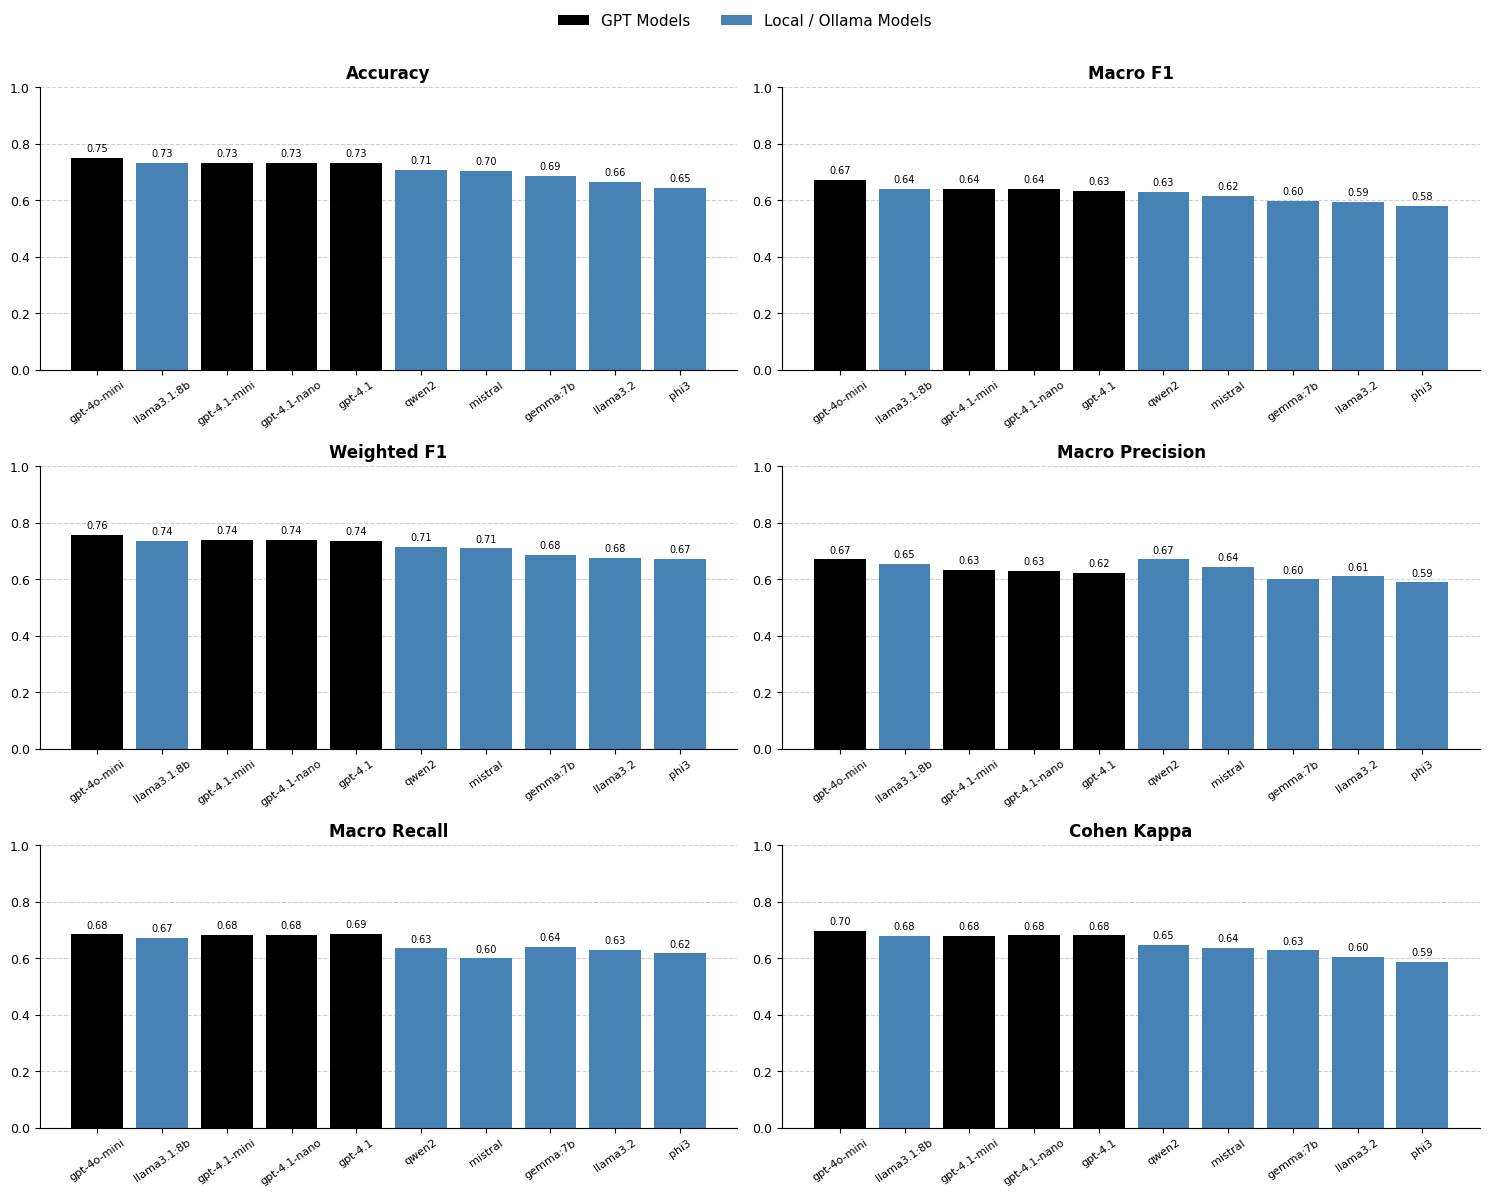

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.patches import Patch

PLOT_DIR = Path("../plots/model_benchmark")
PLOT_DIR.mkdir(parents=True, exist_ok=True)

metric_cols = [
    "accuracy",
    "macro_f1",
    "weighted_f1",
    "macro_precision",
    "macro_recall",
    "cohen_kappa",
]

plot_df = metrics_df.copy()

model_order = (
    plot_df.sort_values("macro_f1", ascending=False)["model_name"]
    .tolist()
)

plot_df["model_name"] = pd.Categorical(
    plot_df["model_name"],
    categories=model_order,
    ordered=True
)

plot_df = plot_df.sort_values("model_name")


def get_model_color(model_name):
    model_name = str(model_name).lower()
    if "gpt" in model_name or model_name.startswith("o"):
        return "black"
    return "steelblue"

# Note: The loop for plot_metric_bar has been removed as per your request 
# to only save and display the combined grid.

# Combined figure
fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(15, 12)
)

axes = axes.flatten()
colors = [get_model_color(m) for m in plot_df["model_name"]]

for ax, metric in zip(axes, metric_cols):
    ax.bar(plot_df["model_name"].astype(str), plot_df[metric], color=colors)

    # --- Added Grid ---
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    ax.set_axisbelow(True)  # Grid behind bars
    # ------------------

    ax.set_title(
        metric.replace("_", " ").title(),
        fontsize=12,
        fontweight="bold"
    )

    ymin = min(0, plot_df[metric].min() * 1.15)
    ymax = max(1.0, plot_df[metric].max() * 1.15)
    ax.set_ylim(ymin, ymax)

    ax.tick_params(axis="x", rotation=35, labelsize=8)
    ax.tick_params(axis="y", labelsize=9)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    for i, value in enumerate(plot_df[metric]):
        offset = 0.015 if value >= 0 else -0.04
        va = "bottom" if value >= 0 else "top"

        ax.text(
            i,
            value + offset,
            f"{value:.2f}",
            ha="center",
            va=va,
            fontsize=7
        )

legend_elements = [
    Patch(facecolor="black", label="GPT Models"),
    Patch(facecolor="steelblue", label="Local / Ollama Models"),
]

fig.legend(
    handles=legend_elements,
    loc="upper center",
    ncol=2,
    frameon=False,
    fontsize=11
)

plt.tight_layout(rect=[0, 0, 1, 0.96])

# Saving only the grid
out_path = PLOT_DIR / "all_model_metrics_bar_charts.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
print("Saved:", out_path)

plt.show()


Grid saved successfully: ../plots/model_benchmark/Confusion_Matrix_All_Model_normalized.png


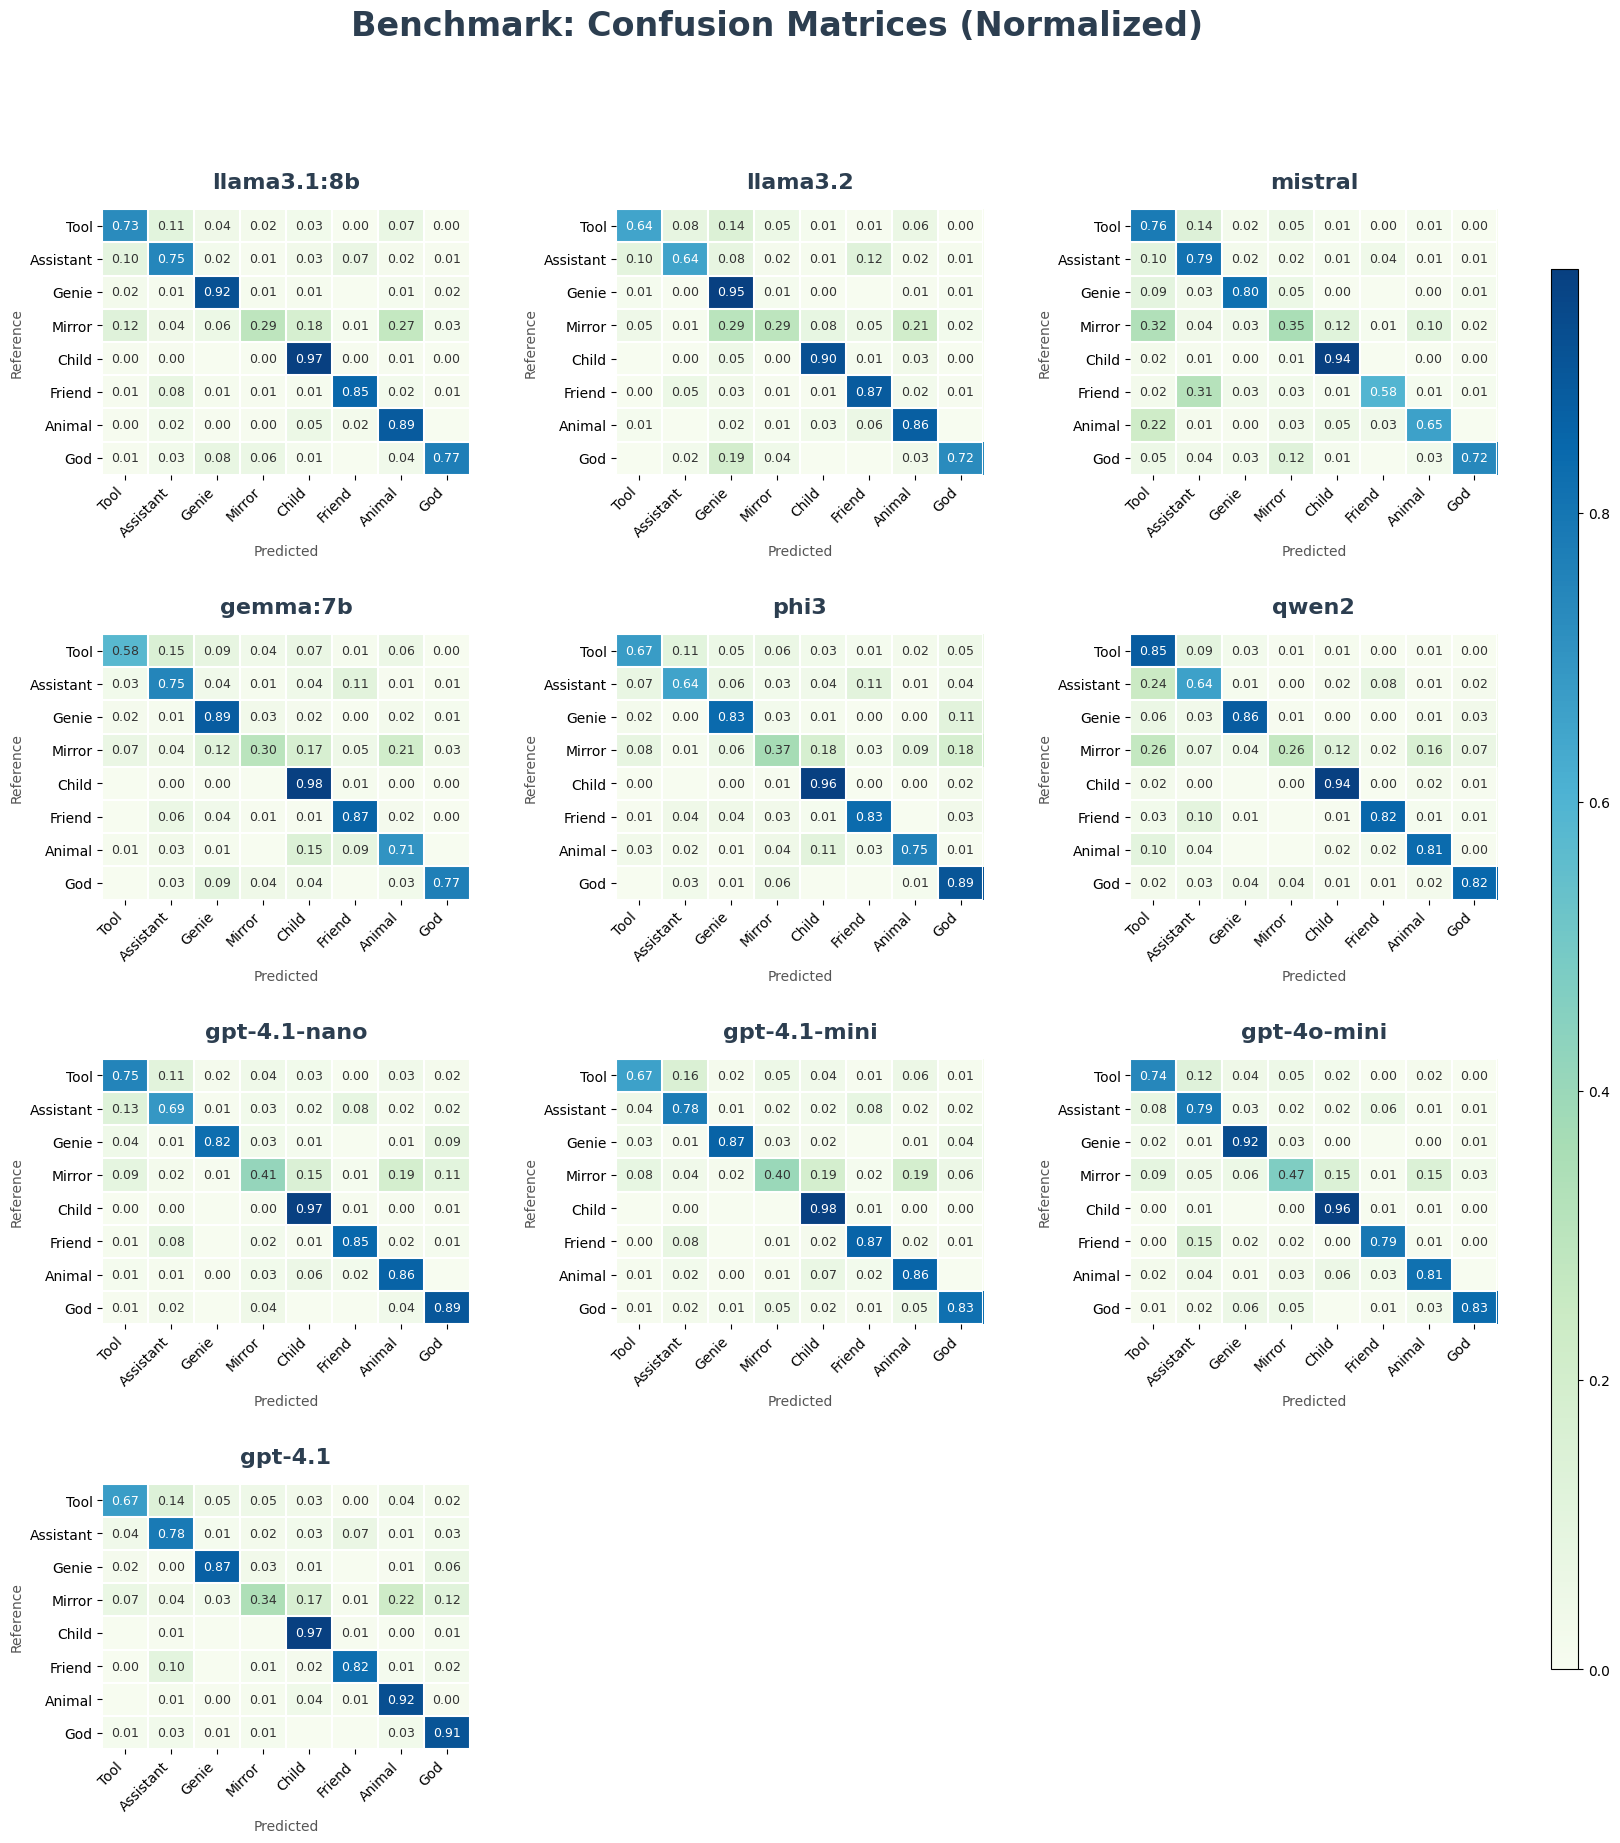

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import math
from pathlib import Path
from sklearn.metrics import confusion_matrix

# Configuration
PLOT_DIR = Path("../plots/model_benchmark")
PLOT_DIR.mkdir(parents=True, exist_ok=True)

# Data Preparation
df_cm = ai_benchmark_df.copy()
df_cm["reference_metaphor"] = df_cm["reference_metaphor"].str.strip().str.title()
df_cm["predicted_metaphor"] = df_cm["predicted_metaphor"].str.strip().str.title()
df_cm = df_cm[df_cm["predicted_metaphor"] != "Error"]

LABEL_ORDER = [
    "Tool", "Assistant", "Genie", "Mirror",
    "Child", "Friend", "Animal", "God"
]

def plot_model_comparison_grid(df, rows=4, normalize=True):
    models = df["model_name"].unique()
    num_models = len(models)
    
    # Calculate columns needed to satisfy the 4-row requirement
    cols = math.ceil(num_models / rows)

    # Increased figsize: 6 units of width per column, 5 units of height per row
    fig, axes = plt.subplots(
        rows, cols, 
        figsize=(cols * 6, rows * 5), 
        facecolor='white'
    )
    
    axes_flat = axes.flatten()

    for i, model_name in enumerate(models):
        ax = axes_flat[i]
        group = df[df["model_name"] == model_name].copy()

        cm = confusion_matrix(
            group["reference_metaphor"],
            group["predicted_metaphor"],
            labels=LABEL_ORDER
        )

        if normalize:
            row_sums = cm.sum(axis=1, keepdims=True)
            cm_display = np.divide(cm.astype(float), row_sums, out=np.zeros_like(cm.astype(float)), where=row_sums!=0)
            fmt = ".2f"
        else:
            cm_display = cm
            fmt = "d"

        # Using the soothing GnBu colormap
        im = ax.imshow(cm_display, interpolation="nearest", aspect="auto", cmap="GnBu")

        ax.set_title(model_name, fontsize=16, fontweight="bold", pad=15, color="#2c3e50")

        # Set ticks for every plot as requested
        ax.set_xticks(np.arange(len(LABEL_ORDER)))
        ax.set_yticks(np.arange(len(LABEL_ORDER)))
        
        # Labels for all images
        ax.set_xticklabels(LABEL_ORDER, rotation=45, ha="right", fontsize=10)
        ax.set_yticklabels(LABEL_ORDER, fontsize=10)
        
        ax.set_xlabel("Predicted", fontsize=10, color="#555555")
        ax.set_ylabel("Reference", fontsize=10, color="#555555")

        # Subtle grid lines
        ax.set_xticks(np.arange(len(LABEL_ORDER) + 1) - .5, minor=True)
        ax.set_yticks(np.arange(len(LABEL_ORDER) + 1) - .5, minor=True)
        ax.grid(which="minor", color="white", linestyle='-', linewidth=1.5)
        ax.tick_params(which="minor", bottom=False, left=False)

        # Annotate cells
        thresh = cm_display.max() * 0.6
        for r in range(cm_display.shape[0]):
            for c in range(cm_display.shape[1]):
                val = cm_display[r, c]
                if val > 0:
                    ax.text(
                        c, r, f"{val:{fmt}}",
                        ha="center", va="center",
                        fontsize=9,
                        color="white" if val > thresh else "#333333"
                    )

        # Hide spines
        for spine in ax.spines.values():
            spine.set_visible(False)

    # Hide unused subplots (e.g., if 10 models in 12 slots)
    for j in range(num_models, len(axes_flat)):
        axes_flat[j].axis('off')

    # Shared colorbar
    fig.subplots_adjust(right=0.9, hspace=0.6, wspace=0.4) # Increased spacing for labels
    cbar_ax = fig.add_axes([0.93, 0.15, 0.015, 0.7])
    fig.colorbar(im, cax=cbar_ax)

    plt.suptitle(
        f"Benchmark: Confusion Matrices ({'Normalized' if normalize else 'Counts'})", 
        fontsize=24, fontweight="bold", y=0.98, color="#2c3e50"
    )

    # Final Save
    suffix = "normalized" if normalize else "counts"
    out_path = PLOT_DIR / f"Confusion_Matrix_All_Model_{suffix}.png"
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    
    print(f"Grid saved successfully: {out_path}")
    plt.show()

# Execution
plot_model_comparison_grid(df_cm, rows=4, normalize=True)

In [6]:
import pandas as pd
gpt_batch_results_df = pd.read_csv('../Data/model_eval/GPT_Batch_results_New_Prompt.csv')
llama_results_df = pd.read_csv("../data/model_eval/llama_results.csv")
ai_benchmark_df = pd.read_csv("../data/model_eval/ai_benchmark_results.csv")
metrics_df = pd.read_csv("../data/model_eval/model_performance.csv")

In [9]:
llama_results_df.head()

,model_name,ai_text,reference_metaphor,predicted_metaphor,latency_seconds,cost_usd,error
0,llama3.1:8b,AI is like making a cake from a box instead of...,tool,tool,10.755451,0.0,NaN
1,llama3.1:8b,AI makes fewer medical mistakes,tool,tool,10.894149,0.0,NaN
2,llama3.1:8b,genie in a bottle - you can ask it to do anyth...,genie,genie,11.249961,0.0,NaN
3,llama3.1:8b,Artificial intelligence is a tool that humans ...,tool,assistant,11.565414,0.0,NaN
4,llama3.1:8b,AI brings back people to life. Basically we ca...,tool,genie,1.117014,0.0,NaN


In [12]:
# GPT cost/token summary
gpt_cost = (
    gpt_batch_results_df
    .groupby("model_name")
    .agg(
        total_cost_usd=("cost_usd", "sum"),
        avg_cost_usd=("cost_usd", "mean"),
        avg_input_tokens=("input_tokens", "mean"),
        avg_output_tokens=("output_tokens", "mean"),
    )
    .reset_index()
)

# LLaMA/Ollama latency summary
llama_latency = (
    llama_results_df
    .dropna(subset=["latency_seconds"])
    .groupby("model_name")
    .agg(
        avg_latency_sec=("latency_seconds", "mean"),
        median_latency_sec=("latency_seconds", "median"),
        min_latency_sec=("latency_seconds", "min"),
        max_latency_sec=("latency_seconds", "max"),
        total_latency_sec=("latency_seconds", "sum"),
    )
    .reset_index()
)

# Merge both into benchmark metrics
final_df = (
    metrics_df
    .merge(gpt_cost, on="model_name", how="left")
    .merge(llama_latency, on="model_name", how="left")
)

# Optional model type flag
final_df["model_type"] = final_df["model_name"].apply(
    lambda x: "GPT" if ("gpt" in str(x).lower() or str(x).lower().startswith("o")) else "Local/Ollama"
)
# Cleaner ordering
final_df = final_df[
    [
        "model_name",
        "model_type",
        "n",
        "accuracy",
        "macro_f1",
        "weighted_f1",
        "macro_precision",
        "macro_recall",
        "cohen_kappa",
        "total_cost_usd",
        "avg_cost_usd",
        "avg_input_tokens",
        "avg_output_tokens",
        "avg_latency_sec",
        "median_latency_sec",
        "min_latency_sec",
        "max_latency_sec",
        "total_latency_sec",
    ]
]

display(final_df.sort_values("macro_f1", ascending=False))

,model_name,model_type,n,accuracy,macro_f1,weighted_f1,macro_precision,macro_recall,cohen_kappa,total_cost_usd,avg_cost_usd,avg_input_tokens,avg_output_tokens,avg_latency_sec,median_latency_sec,min_latency_sec,max_latency_sec,total_latency_sec
0,gpt-4o-mini,GPT,4147,0.748493,0.671665,0.758239,0.670234,0.684325,0.698387,0.196096,0.000047,310.702435,1.134796,NaN,NaN,NaN,NaN,NaN
1,llama3.1:8b,Local/Ollama,4147,0.733301,0.641185,0.736207,0.653799,0.672045,0.680665,NaN,NaN,NaN,NaN,1.017266,0.952835,0.706688,11.565414,4218.602020
2,gpt-4.1-mini,GPT,4147,0.731131,0.641023,0.738076,0.632297,0.681703,0.679867,0.522764,0.000126,310.702435,1.110924,NaN,NaN,NaN,NaN,NaN
3,gpt-4.1-nano,GPT,4147,0.733542,0.639749,0.740075,0.628573,0.683148,0.680734,0.130681,0.000032,310.702435,1.104654,NaN,NaN,NaN,NaN,NaN
4,gpt-4.1,GPT,4147,0.731854,0.633535,0.736062,0.621663,0.687562,0.681007,2.614182,0.000630,310.702435,1.121775,NaN,NaN,NaN,NaN,NaN
5,qwen2,Local/Ollama,4147,0.708223,0.629230,0.714850,0.670347,0.634729,0.645918,NaN,NaN,NaN,NaN,0.816095,0.749213,0.531776,9.351449,3384.347703
6,mistral,Local/Ollama,4147,0.702677,0.616002,0.709452,0.642683,0.599349,0.636672,NaN,NaN,NaN,NaN,1.010020,0.937204,0.590105,10.225834,4188.553934
7,gemma:7b,Local/Ollama,4147,0.685797,0.597340,0.684883,0.599521,0.640093,0.627940,NaN,NaN,NaN,NaN,1.047520,0.979473,0.717006,7.733255,4344.063705
8,llama3.2,Local/Ollama,4147,0.663853,0.594754,0.675304,0.610118,0.629129,0.604508,NaN,NaN,NaN,NaN,0.469035,0.440743,0.327544,5.615594,1945.087773
9,phi3,Local/Ollama,4147,0.645045,0.580827,0.672105,0.588695,0.617382,0.585801,NaN,NaN,NaN,NaN,0.680074,0.595744,0.357366,7.318959,2820.268453


In [24]:
final_df.to_csv("../data/model_eval/model_performance_latency-cost.csv", index=False)

Saved: ../plots/model_benchmark/gpt_performance_per_dollar_grid.png


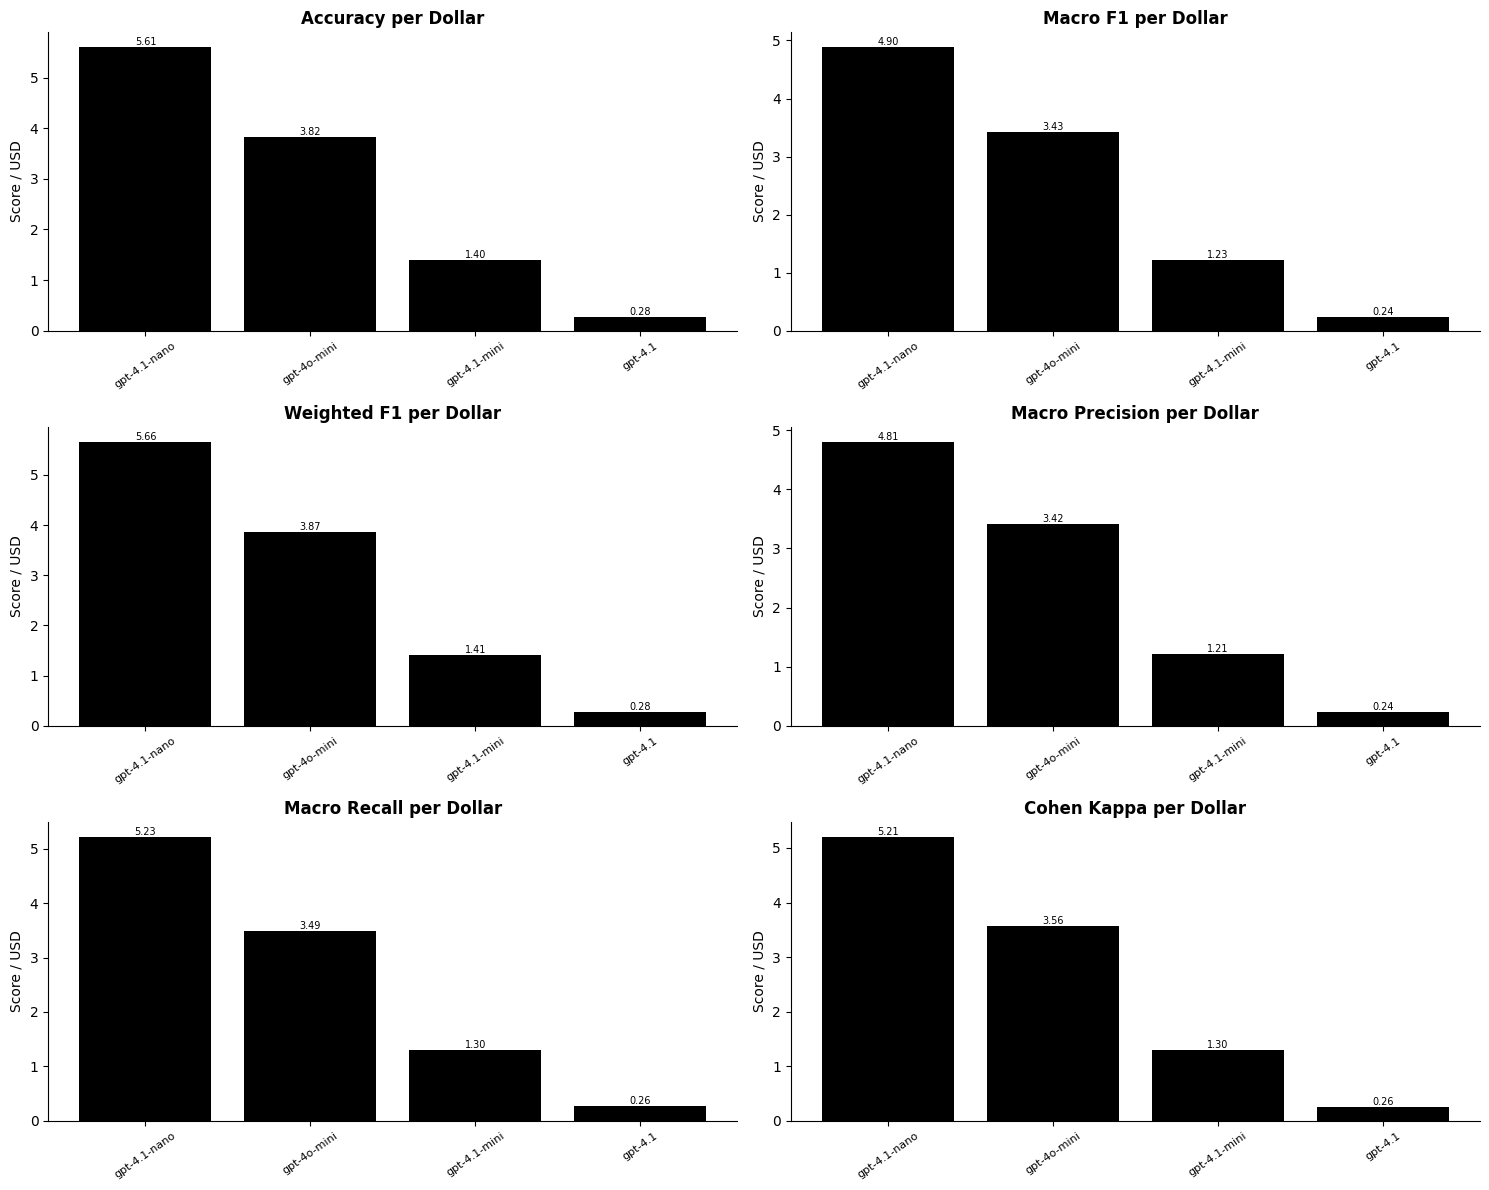

In [20]:
import matplotlib.pyplot as plt
from pathlib import Path

PLOT_DIR = Path("../plots/model_benchmark")
PLOT_DIR.mkdir(parents=True, exist_ok=True)

performance_metrics = [
    "accuracy",
    "macro_f1",
    "weighted_f1",
    "macro_precision",
    "macro_recall",
    "cohen_kappa",
]

# -------------------------
# GPT: performance per dollar
# -------------------------
gpt_plot = final_df[final_df["model_type"] == "GPT"].copy()

for metric in performance_metrics:
    gpt_plot[f"{metric}_per_dollar"] = (
        gpt_plot[metric] / gpt_plot["total_cost_usd"]
    )

fig, axes = plt.subplots(3, 2, figsize=(15, 12))
axes = axes.flatten()

for ax, metric in zip(axes, performance_metrics):
    col = f"{metric}_per_dollar"
    temp = gpt_plot.sort_values(col, ascending=False)

    ax.bar(temp["model_name"], temp[col], color="black")

    ax.set_title(f"{metric.replace('_', ' ').title()} per Dollar", fontweight="bold")
    ax.set_ylabel("Score / USD")
    ax.tick_params(axis="x", rotation=35, labelsize=8)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    for i, v in enumerate(temp[col]):
        ax.text(i, v, f"{v:.2f}", ha="center", va="bottom", fontsize=7)

plt.tight_layout()

out_path = PLOT_DIR / "gpt_performance_per_dollar_grid.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
print("Saved:", out_path)

plt.show()

Saved: ../plots/model_benchmark/llama_performance_per_latency_grid.png


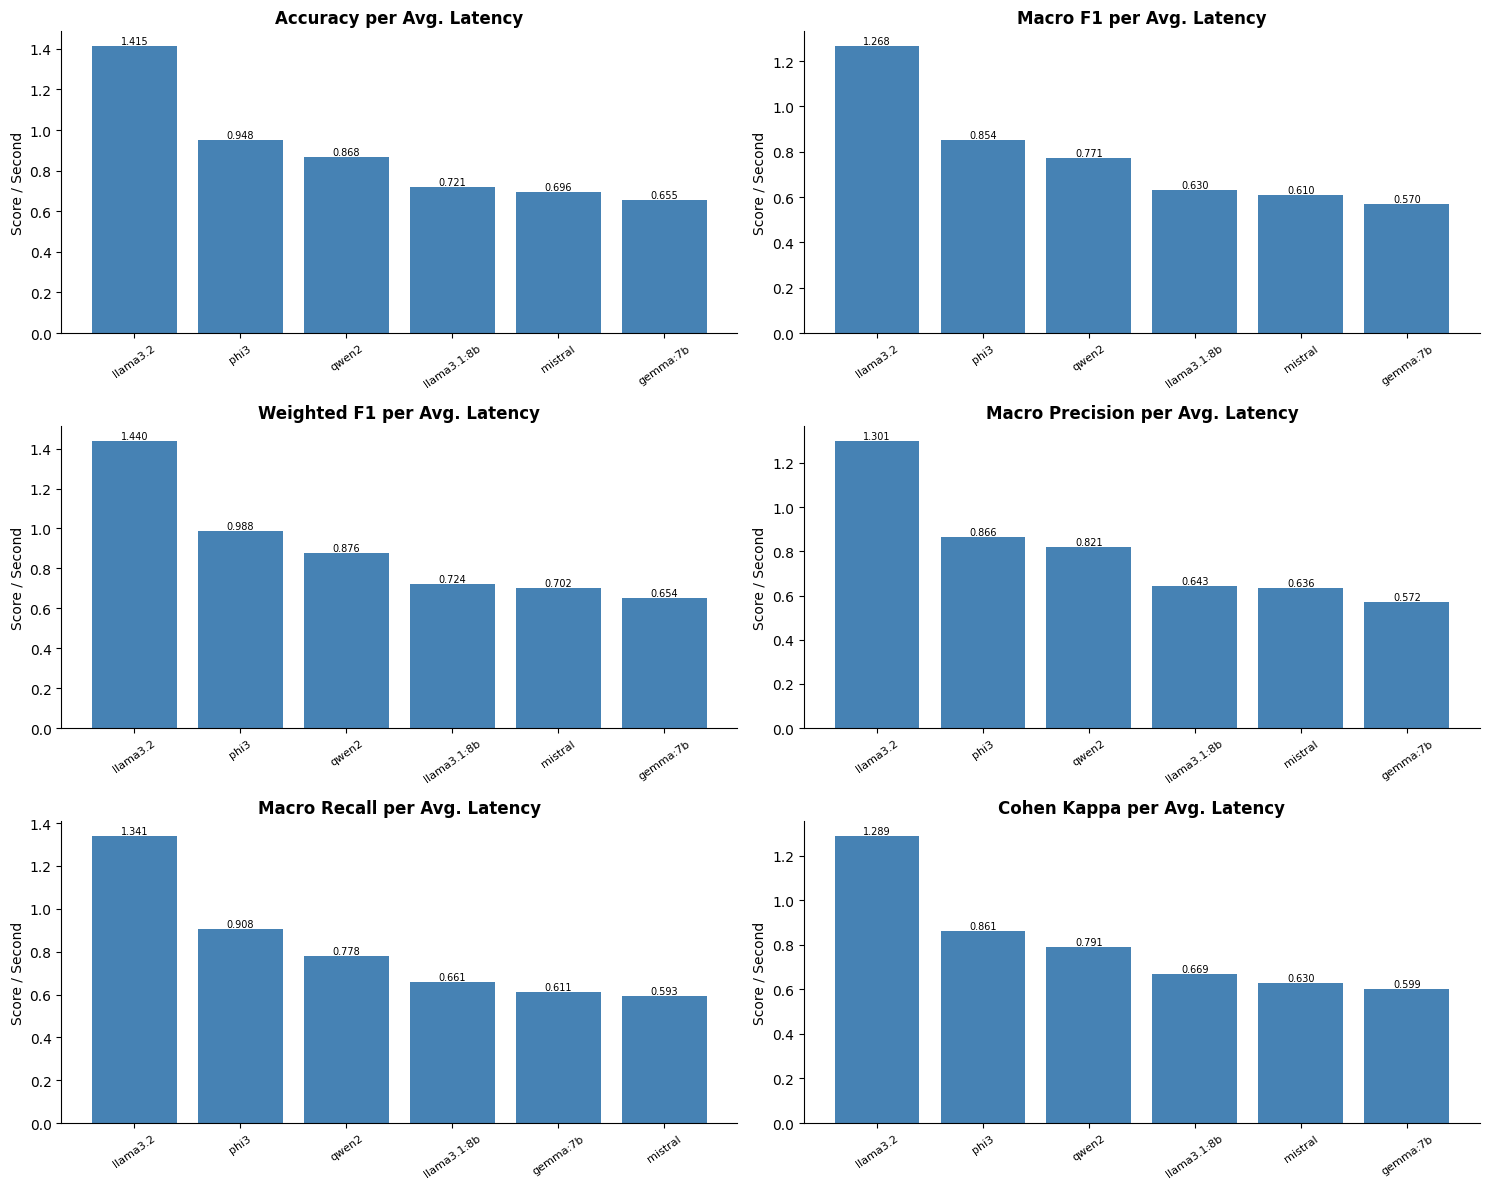

In [21]:
# -------------------------
# LLaMA/Ollama: performance per latency
# -------------------------
llama_plot = final_df[final_df["model_type"] == "Local/Ollama"].copy()

for metric in performance_metrics:
    llama_plot[f"{metric}_per_latency"] = (
        llama_plot[metric] / llama_plot["avg_latency_sec"]
    )

fig, axes = plt.subplots(3, 2, figsize=(15, 12))
axes = axes.flatten()

for ax, metric in zip(axes, performance_metrics):
    col = f"{metric}_per_latency"
    temp = llama_plot.sort_values(col, ascending=False)

    ax.bar(temp["model_name"], temp[col], color="steelblue")

    ax.set_title(f"{metric.replace('_', ' ').title()} per Avg. Latency", fontweight="bold")
    ax.set_ylabel("Score / Second")
    ax.tick_params(axis="x", rotation=35, labelsize=8)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    for i, v in enumerate(temp[col]):
        ax.text(i, v, f"{v:.3f}", ha="center", va="bottom", fontsize=7)

plt.tight_layout()

out_path = PLOT_DIR / "llama_performance_per_latency_grid.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
print("Saved:", out_path)

plt.show()

# Model Benchmark: Performance, Cost, and Latency Analysis

## 1. Overall Performance Comparison

Across all models, we observe a clear separation between high-performing GPT models and local (Ollama) models, though the gap is not drastic.

The best-performing model is **gpt-4o-mini**, achieving:
- Accuracy ≈ 0.75  
- Macro F1 ≈ 0.67  

Other GPT models (**gpt-4.1, gpt-4.1-mini, gpt-4.1-nano**) perform very similarly, indicating diminishing returns at higher cost tiers.

Among local models:
- **llama3.1:8b** is the strongest (Macro F1 ≈ 0.64)  
- Followed by **qwen2** and **mistral**  
- Smaller models like **phi3** and **gemma:7b** lag behind  

**Key takeaway:** Performance differences are relatively small (~0.03–0.04 F1 gap), suggesting that model choice should be driven by efficiency (cost/latency), not just accuracy.

---

## 2. Confusion Matrix Insights

The confusion matrices reveal systematic patterns in model behavior.

### Strongly Learned Metaphors
Across models, the following categories are consistently well-classified:
- Genie  
- Child  
- Animal  
- God  

These categories show:
- High diagonal dominance (≥ 0.85 in many cases)  
- Clear semantic boundaries  

### Weak / Confused Categories
Certain metaphor classes are consistently harder:
- Mirror  
- Assistant  
- Tool  

Common confusions include:
- Tool ↔ Assistant  
- Mirror ↔ Tool / Child  
- Assistant ↔ Tool  

This indicates that models struggle with functional or role-based metaphors, which are semantically overlapping and context-dependent.

### Model-Specific Observations
- GPT models show more consistent diagonals and better separation between similar classes  
- Local models exhibit more off-diagonal spread and higher confusion for abstract metaphors  

---

## 3. Cost vs Performance (GPT Models)

When evaluating performance per dollar, a clear hierarchy emerges.

### Best Cost-Efficient Model
- **gpt-4.1-nano**
  - Highest score-per-dollar across all metrics  
  - ~2× more efficient than gpt-4o-mini  
  - ~10× more efficient than gpt-4.1  

### Middle Tier
- **gpt-4o-mini**
  - Best raw performance  
  - Strong balance between cost and accuracy  

### Worst Efficiency
- **gpt-4.1**
  - High cost  
  - Minimal performance improvement  

**Key insight:** Higher-cost models do not provide proportional performance gains.

---

## 4. Latency vs Performance (Local Models)

Latency analysis highlights a different trade-off.

### Best Latency-Performance Model
- **llama3.2**
  - Highest performance per second across all metrics  
  - Strong balance of speed and accuracy  

### Strong Alternatives
- **phi3**
- **qwen2**

These models offer slightly lower performance but significantly better latency efficiency than larger models.

### Slower / Less Efficient Models
- **llama3.1:8b**
- **mistral**
- **gemma:7b**

These models are slower and do not compensate with higher performance.

---

## 5. Key Trade-Off Summary

### Cost Efficiency (GPT)
- Best: **gpt-4.1-nano**  
- Balanced: **gpt-4o-mini**  
- Worst: **gpt-4.1**  

### Latency Efficiency (Local Models)
- Best: **llama3.2**  
- Balanced: **phi3 / qwen2**  
- Worst: **mistral / gemma**  

### Accuracy / Performance
- Best overall: **gpt-4o-mini**  
- Best local: **llama3.1:8b**  

---

## 6. Final Recommendation

- If cost is the priority: use **gpt-4.1-nano**  
- If best performance is required: use **gpt-4o-mini**  
- If running locally: use **llama3.2**  

---

## 7. Overall Conclusion

This benchmark demonstrates that:
- Prompt design and model efficiency matter more than model size  
- Smaller models can outperform larger ones when normalized by cost or latency  
- Most classification errors arise from semantic overlap between metaphor categories  

**Final insight:** The optimal model is not the most powerful one, but the one that provides the best trade-off between performance, cost, and latency.


## Model Performance (LLAMA 3.2, GPT-4.1-nano) Per Metaphor Class

In [27]:
selected_models = ["gpt-4.1-nano", "llama3.2"]

df_compare = ai_benchmark_df[
    ai_benchmark_df["model_name"].isin(selected_models)
].copy()

In [30]:
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd

metaphors = sorted(df_compare["reference_metaphor"].unique())

rows = []

for model in selected_models:
    df_m = df_compare[df_compare["model_name"] == model]

    for m in metaphors:
        y_true = (df_m["reference_metaphor"] == m).astype(int)
        y_pred = (df_m["predicted_metaphor"] == m).astype(int)

        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)

        support = y_true.sum()

        rows.append({
            "model": model,
            "metaphor": m,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "support": support
        })

per_metaphor_df = pd.DataFrame(rows)

In [32]:
per_metaphor_df = per_metaphor_df[
    per_metaphor_df["support"] > 0
]

In [33]:
f1_pivot = per_metaphor_df.pivot(
    index="metaphor",
    columns="model",
    values="f1"
).reset_index()

f1_pivot = f1_pivot.sort_values(
    by="gpt-4.1-nano",
    ascending=False
)

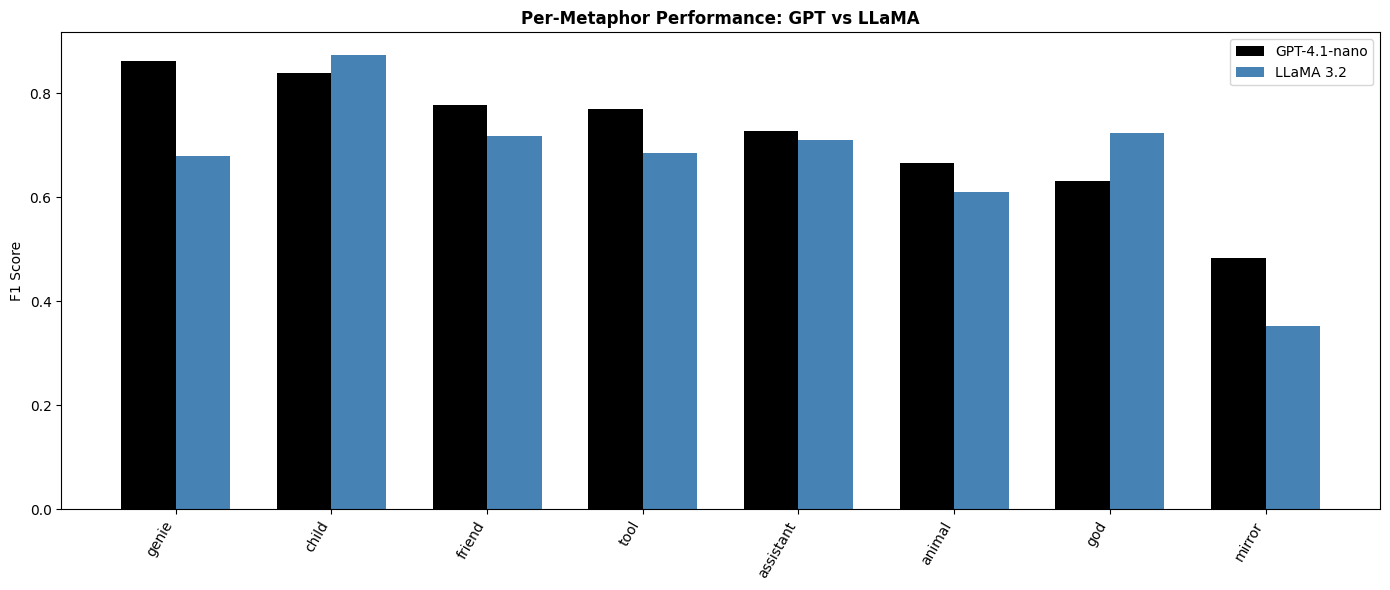

In [35]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(len(f1_pivot))
width = 0.35

plt.figure(figsize=(14,6))

plt.bar(
    x - width/2,
    f1_pivot["gpt-4.1-nano"],
    width,
    label="GPT-4.1-nano",
    color="black"
)

plt.bar(
    x + width/2,
    f1_pivot["llama3.2"],
    width,
    label="LLaMA 3.2",
    color="steelblue"
)

plt.xticks(x, f1_pivot["metaphor"], rotation=60, ha="right")

plt.ylabel("F1 Score")
plt.title("Per-Metaphor Performance: GPT vs LLaMA", fontweight="bold")

plt.legend()
plt.tight_layout()
plt.savefig(PLOT_DIR / "best_model_performance_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

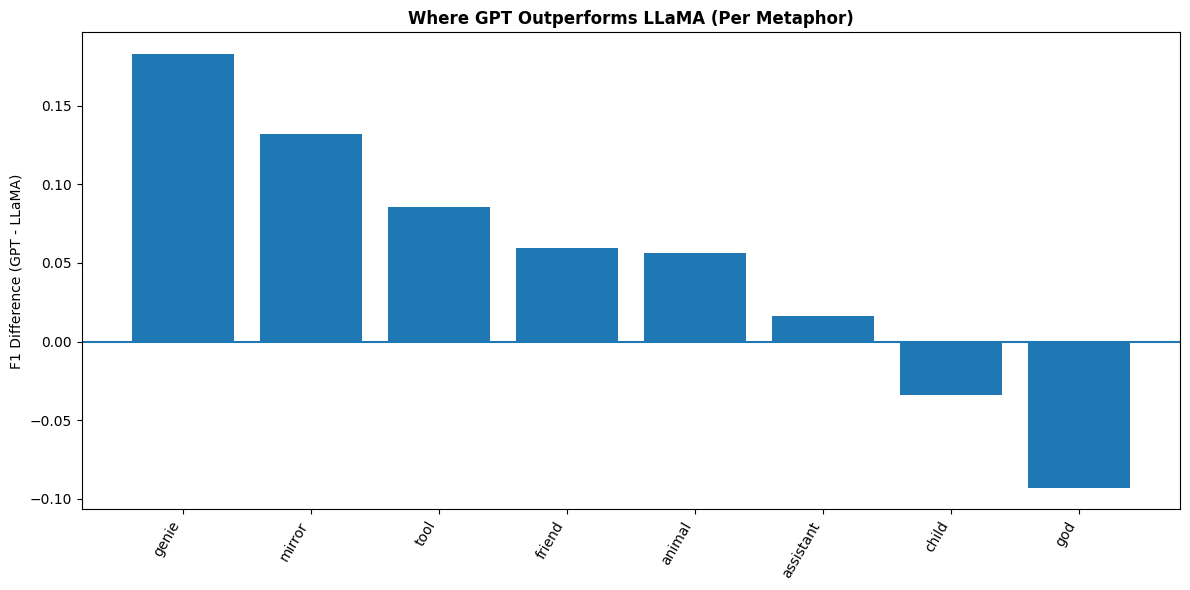

In [40]:
f1_pivot["diff"] = (
    f1_pivot["gpt-4.1-nano"] - f1_pivot["llama3.2"]
)

f1_pivot = f1_pivot.sort_values("diff", ascending=False)

plt.figure(figsize=(12,6))

plt.bar(f1_pivot["metaphor"], f1_pivot["diff"])

plt.axhline(0)

plt.xticks(rotation=60, ha="right")
plt.ylabel("F1 Difference (GPT - LLaMA)")
plt.title("Where GPT Outperforms LLaMA (Per Metaphor)", fontweight="bold")

plt.tight_layout()
plt.savefig(PLOT_DIR / "gpt_vs_llama_f1_difference.png", dpi=300, bbox_inches="tight")
plt.show()

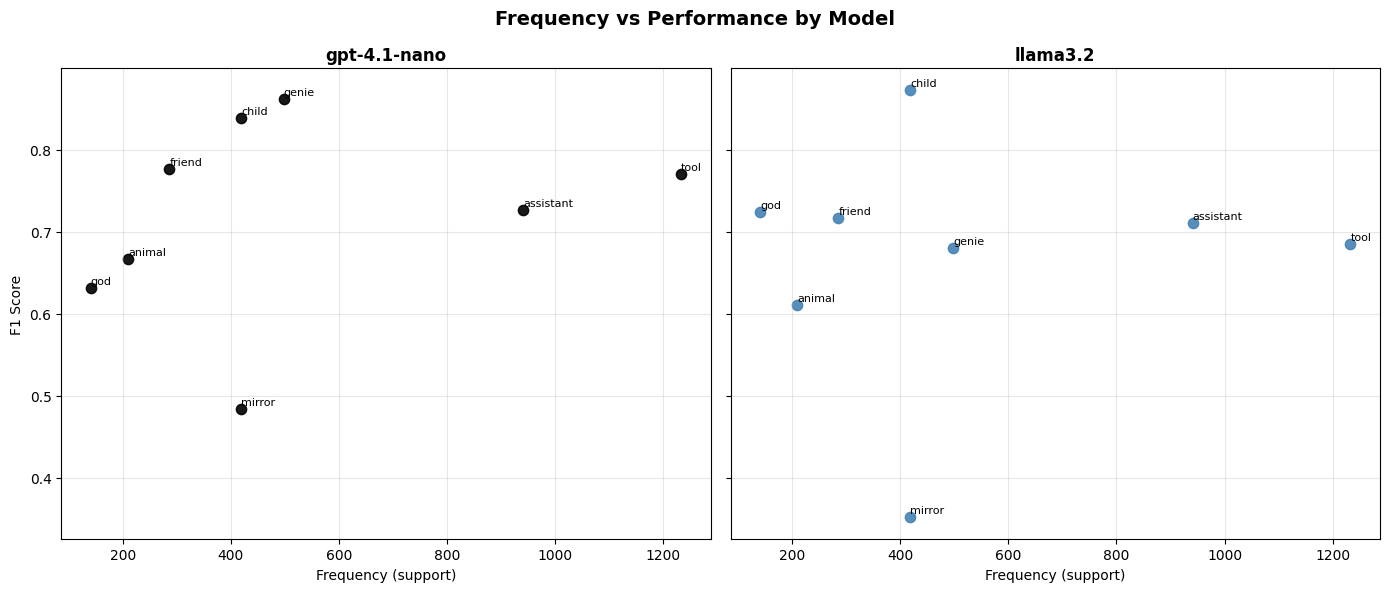

In [39]:
import matplotlib.pyplot as plt

models_to_plot = ["gpt-4.1-nano", "llama3.2"]
model_colors = {
    "gpt-4.1-nano": "black",
    "llama3.2": "steelblue",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

for ax, model_name in zip(axes, models_to_plot):
    model_df = per_metaphor_df[per_metaphor_df["model"] == model_name][["metaphor", "support", "f1"]]

    ax.scatter(
        model_df["support"],
        model_df["f1"],
        s=55,
        color=model_colors[model_name],
        alpha=0.9,
    )

    for _, row in model_df.iterrows():
        ax.text(row["support"] + 0.05, row["f1"] + 0.005, row["metaphor"], fontsize=8)

    ax.set_title(f"{model_name}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Frequency (support)")
    ax.grid(alpha=0.3)

axes[0].set_ylabel("F1 Score")
fig.suptitle("Frequency vs Performance by Model", fontsize=14, fontweight="bold")
plt.tight_layout()

plt.savefig(PLOT_DIR / "frequency_vs_f1_grid.png", dpi=300, bbox_inches="tight")
plt.show()

## Per-Metaphor Interpretation

### GPT-4.1-nano vs LLaMA 3.2

Both models perform well on core categories, but their strengths are different by metaphor type.

### 1. Overall Pattern

- GPT-4.1-nano is stronger on abstract and interpretive metaphors.
- LLaMA 3.2 is competitive on more intuitive, human-centered metaphors.
- The gap is category-specific rather than uniformly better or worse across all classes.

### 2. Where GPT-4.1-nano Leads

- **Genie** (largest margin, ~+0.18 F1)
- **Mirror** (~+0.13 F1)
- **Tool** (~+0.09 F1)
- **Friend**, **Animal**, **Assistant** (smaller gains)

Interpretation:
- GPT appears better at non-literal, contextual, and conceptual framing.

### 3. Where LLaMA 3.2 Leads

- **Child** (~-0.03 F1 from GPT perspective)
- **God** (~-0.09 F1 from GPT perspective)

Interpretation:
- LLaMA performs well on direct, intuitive analogy-based metaphors.

### 4. Difference Plot Insights

- Largest model separation appears in semantically abstract classes.
- Near-parity classes (for example, **Assistant**, **Animal**) suggest easier semantic boundaries.
- The errors are systematic, not random.

### 5. Frequency vs Performance

#### GPT-4.1-nano

- High-frequency classes (for example, **Tool**, **Assistant**) are not always top-performing.
- Strong classes (for example, **Genie**) are not necessarily most frequent.
- Performance is influenced more by semantic clarity than frequency alone.

#### LLaMA 3.2

- Strong on **Child**, **Friend**, **God**.
- Weaker on **Mirror** despite moderate support.
- This suggests continued difficulty with abstract framing even with available examples.

### 6. Core Takeaways

- Model strengths are complementary:
  - GPT: abstract/interpretive reasoning
  - LLaMA: intuitive/human-like semantic mapping
- Confusions cluster around overlapping categories (for example, **Tool** vs **Assistant**).
- Class frequency is not the main driver of F1 performance.

### 7. Practical Recommendation

- Prefer **GPT-4.1-nano** for interpretive or abstract metaphor analysis.
- Prefer **LLaMA 3.2** when speed/efficiency is needed for simpler semantic categorization.

### Final Interpretation

Performance differences between GPT-4.1-nano and LLaMA 3.2 are driven primarily by **semantic difficulty of metaphor categories**, not just model size or overall benchmark score. Model choice should therefore be matched to the reasoning style required by the target task.